In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker, colors

In [48]:

n = 10
residual_coef = 0.8 # 0.8 for cold-rolled steel, 0.6 for hot-rolled steel
bmax = 1.75
br = bmax * residual_coef 
bsat = 2.03

def f(b_residual, b_regular):
    r = (bsat-b_residual-b_regular)/b_regular
    r = np.clip(r, -1, 1)
    return 0.9*np.arccos(r)


b_residual = np.linspace(0, br, 10*n)
b_regular = np.linspace(0, bmax, 10*n)
X, Y = np.meshgrid(b_residual, b_regular)
Z = f(X, Y)
print(Z.max(), Z.min())
print(f(X, Y)[-1:])
print(f(X, Y)[:1])


2.0387651331793073 0.0
[[1.26909511 1.27645795 1.28381155 1.29115642 1.29849309 1.30582207
  1.31314387 1.32045899 1.32776793 1.33507119 1.34236926 1.34966263
  1.35695179 1.36423723 1.37151942 1.37879884 1.38607599 1.39335132
  1.40062532 1.40789847 1.41517124 1.4224441  1.42971754 1.43699202
  1.44426802 1.45154601 1.45882649 1.46610992 1.47339679 1.48068757
  1.48798277 1.49528285 1.50258833 1.50989968 1.51721741 1.52454202
  1.53187401 1.5392139  1.5465622  1.55391944 1.56128613 1.56866281
  1.57605002 1.5834483  1.59085821 1.59828031 1.60571516 1.61316334
  1.62062543 1.62810203 1.63559374 1.64310118 1.65062498 1.65816576
  1.66572417 1.67330089 1.68089658 1.68851193 1.69614765 1.70380445
  1.71148306 1.71918425 1.72690877 1.73465742 1.742431   1.75023034
  1.7580563  1.76590974 1.77379155 1.78170267 1.78964403 1.79761662
  1.80562143 1.8136595  1.82173191 1.82983974 1.83798415 1.8461663
  1.8543874  1.86264873 1.87095158 1.87929729 1.88768728 1.89612299
  1.90460594 1.91313768 1.

C:\Users\sunjuichih\AppData\Local\Temp\ipykernel_14652\1381896083.py:8: RuntimeWarning: divide by zero encountered in divide
  r = (bsat-b_residual-b_regular)/b_regular


In [49]:
Z.max()

np.float64(2.0387651331793073)

C:\Users\sunjuichih\AppData\Local\Temp\ipykernel_14652\1381896083.py:8: RuntimeWarning: divide by zero encountered in divide
  r = (bsat-b_residual-b_regular)/b_regular


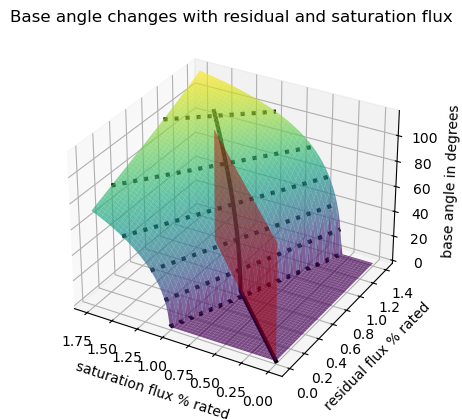

In [54]:
# plotting x = y plane
X1 = np.linspace(0, br, 10*n)
Z1 = np.linspace(0, np.pi/2, 10*n)
X1, Z1 = np.meshgrid(X1, Z1)
Y1 = X1*residual_coef  # assuming x = y plane

# plotting intersection of x=y plane and the surface
X2 = np.linspace(0, br, 10*n)
Y2 = X2*residual_coef  # x = y
Z2 = f(X2, Y2)



angle_levels = np.linspace(0, 180,10)
#print(angle_levels)
ax = plt.axes(projection='3d')
ax.contour(Y, X, Z*180/np.pi, alpha=1, linewidths=3, colors='black', linestyles='dotted', levels=angle_levels)
ax.plot_surface(Y, X, Z*180/np.pi, cmap='viridis', edgecolor='none', alpha=0.7)
ax.plot_surface(X1, Y1, Z1*180/np.pi, color='red', alpha=0.5) 
ax.plot(X2, Y2, Z2*180/np.pi, color='black', linewidth=3)
ax.set_xlabel("saturation flux % rated")
ax.set_ylabel("residual flux % rated")
ax.set_zlabel("base angle in degrees")
ax.invert_xaxis()
#ax.view_init(-170, 210)
ax.set_title("Base angle changes with residual and saturation flux")
plt.show()

Text(0.5, 1.0, 'Ideal inrush current waveform')

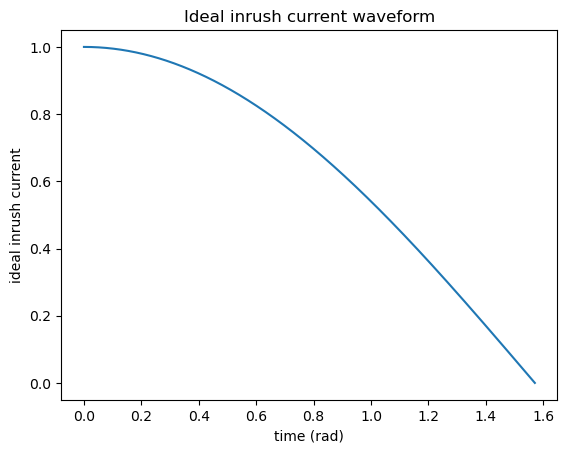

In [7]:
alpha = 2*np.pi/4
def ideal_inrush_current(x):
    return np.cos(x) - np.cos(alpha)

delta_t = 0.00001
#t_grid = np.linspace(-alpha, 2*np.pi+alpha, int(1/delta_t))
t_grid = np.linspace(0, alpha, int(1/delta_t))
I = ideal_inrush_current(t_grid)
I[I < 0] = 0
plt.plot(t_grid, I)
plt.xlabel("time (rad)")
plt.ylabel("ideal inrush current")
plt.title("Ideal inrush current waveform")

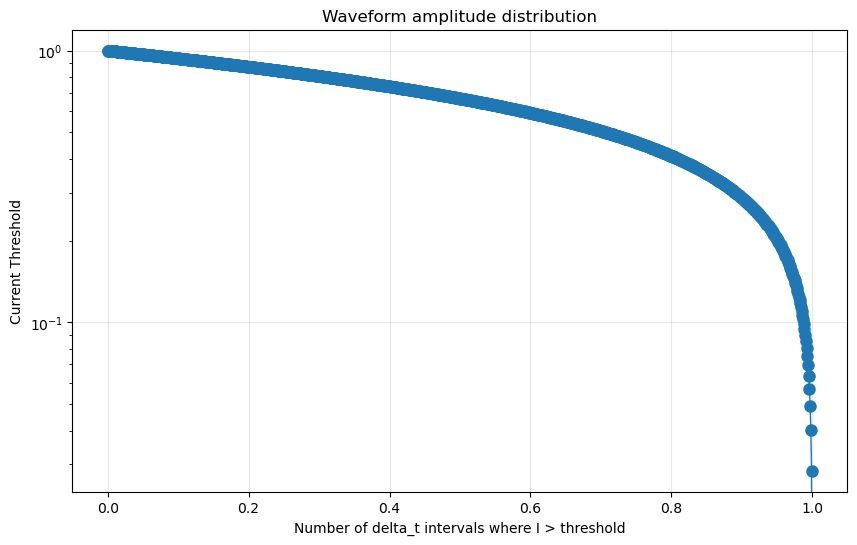

In [8]:
thresholds = np.linspace(0, I.max(), 1000)
counts = [np.sum(I > threshold)/len(I) for threshold in thresholds]

plt.figure(figsize=(10, 6))
plt.plot( thresholds, counts,marker='o', linewidth=1, markersize=8)
plt.ylabel("Current Threshold")
plt.xlabel("Number of delta_t intervals where I > threshold")
plt.title("Waveform amplitude distribution")
plt.grid(True, alpha=0.3)
#plt.xscale('log')
plt.yscale('log')
plt.show()

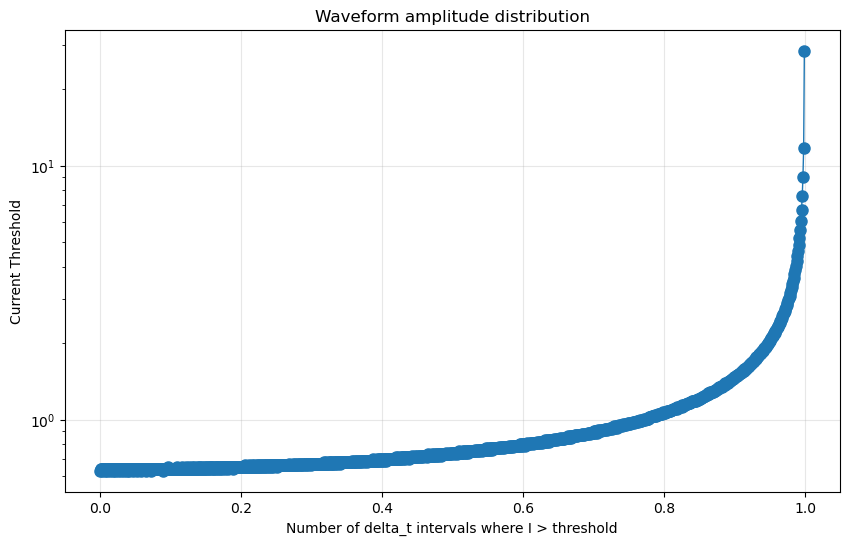

In [9]:
thresholds = np.linspace(0, I.max(), 1000)
derivative_counts = []
for i in range(len(thresholds)-1):
    derivative = (counts[i+1]-counts[i])/(thresholds[i+1]-thresholds[i])
    derivative_counts.append(-derivative)

plt.figure(figsize=(10, 6))
plt.plot( thresholds[:-1], derivative_counts,marker='o', linewidth=1, markersize=8)
plt.ylabel("Current Threshold")
plt.xlabel("Number of delta_t intervals where I > threshold")
plt.title("Waveform amplitude distribution")
plt.grid(True, alpha=0.3)
#plt.xscale('log')
plt.yscale('log')
plt.show()